# Cox Regression Penalized

### Imports

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

# Clinical Data
df = pd.read_csv("./data/X_train/clinical_train.csv")
df_eval = pd.read_csv("./data/X_test/clinical_test.csv")

# Molecular Data
maf_df = pd.read_csv("./data/X_train/molecular_train.csv")
maf_eval = pd.read_csv("./data/X_test/molecular_test.csv")

target_df = pd.read_csv("./data/target_train.csv")

# TODO : Uncomment for test data ??
"""
target_df_test = pd.read_csv("./data/target_test.csv")
"""
# Preview the data
df.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


### Cleaning

In [3]:
# Drop rows where 'OS_YEARS' is NaN if conversion caused any issues
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)

# Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

OS_STATUS    float64
OS_YEARS     float64
dtype: object


0. Parsing functions

In [4]:
def parse_PROTEIN_CHANGE(protein):
    protein = str(protein)

    if len(protein) == 0 or len(protein) == 1:
        return pd.NA
    
    try:
        protein = str(protein.split('.')[1])
    
    except IndexError:
        return pd.NA
    
    if protein == '?' or protein[0] == '*':
        return pd.NA
    
    else:
        return protein[0]
    
def parse_REF(ref):
    ref = str(ref)
    if len(ref) == 0:
        return pd.NA
    elif ref[0] == '-':
        return pd.NA
    else:
        return ref[0]
    
def parse_ALT(ref):
    ref = str(ref)
    if len(ref) == 0:
        return pd.NA
    elif ref[0] == '-':
        return pd.NA
    else:
        return ref[0]
    
def parse_CHR(chr):
    chr = str(chr).lower()
    if chr not in ['1','2','3','4','5','6','7','8','9','10',
                   '11','12','13','14','15','16','17','18',
                   '19','20','21','22','X','Y']:
        return pd.NA
    else:
        return chr
    
def parse_GENE(gene):
    gene = str(gene)
    if len(gene) == 0:
        return pd.NA
    elif len(gene) < 4:
        return gene
    else:
        return gene[0:4]
    
def parse_EFFECT(effect):
    return effect

def parse_cytogenetics(karyotype):
    karyotype = str(karyotype)
    results = []
    segments = karyotype.split("/")  # sépare 46,xx[...] / 45,xx[...]

    for seg in segments:
        anomalies = re.findall(r"(del\(\d+\)|add\(\d+\)|\+\d+|-\d+)", seg)
        anomalies = [anomaly for anomaly in anomalies if anomaly.startswith(('del', 'add')) or (anomaly[0] in ['+', '-'] and anomaly[1:].isdigit() and int(anomaly[1:]) <= 21)]
        results.extend(anomalies)

    return results

def parse_RELEVANT():
    return ['-7', 'TP53', 'HB', '-7','Nmut']

1. Extracting number of somatic mutations and cytogenetics parsed

In [5]:
total_features = set()

# Step: Extract the number of somatic mutations per patient
# Group by 'ID' and count the number of mutations (rows) per patient
tmp = maf_df.groupby('ID').size().reset_index(name='Nmut')
tmp_eval = maf_eval.groupby('ID').size().reset_index(name='Nmut')

total_features.add('Nmut')

# Merge with the training dataset and replace missing values in 'Nmut' with 0
df_2 = df.merge(tmp, on='ID', how='left').fillna({'Nmut': 0})
df_eval2 = df_eval.merge(tmp_eval, on='ID', how='left').fillna({'Nmut': 0})

df_2['CYTOGENETICS_ABNORMALITIES'] = df_2['CYTOGENETICS'].apply(parse_cytogenetics)
df_eval2['CYTOGENETICS_ABNORMALITIES'] = df_eval2['CYTOGENETICS'].apply(parse_cytogenetics)

from sklearn.preprocessing import MultiLabelBinarizer
import warnings

# Initialize the MultiLabelBinarizer
mlb = MultiLabelBinarizer()

# One-hot encode the CYTOGENETICS_ABNORMALITIES column
cytogenetics_encoded = mlb.fit_transform(df_2['CYTOGENETICS_ABNORMALITIES'])

cytogenetics_encoded_eval = mlb.transform(df_eval2['CYTOGENETICS_ABNORMALITIES'])

# Create a DataFrame for the encoded features
cytogenetics_df = pd.DataFrame(cytogenetics_encoded, columns=mlb.classes_, index=df_2.index)
cytogenetics_df_eval = pd.DataFrame(cytogenetics_encoded_eval, columns=mlb.classes_, index=df_eval2.index)

cyto_features = set()
for col in cytogenetics_df:
    if col in cytogenetics_df_eval:
        cyto_features.add(col)

total_features.update(list(cyto_features))
# Merge the one-hot encoded features back into the original DataFrame
df_2 = pd.concat([df_2, cytogenetics_df[list(cyto_features)]], axis=1)
df_eval2 = pd.concat([df_eval2, cytogenetics_df_eval[list(cyto_features)]], axis=1)

print("Are the columns the same in both datasets : ", all(df_eval2.columns == df_2.columns))
print("Features so far : ", total_features)
df_2.head()

Are the columns the same in both datasets :  True
Features so far :  {'+18', '+5', '+15', 'del(2)', 'del(10)', '+17', 'del(13)', 'add(22)', '+21', 'add(1)', '-14', 'add(15)', 'del(15)', 'del(5)', '-20', '-12', 'del(11)', 'del(17)', '-13', '+4', '-15', '+20', 'del(9)', 'del(8)', '+11', 'add(2)', '+10', 'add(20)', 'del(19)', 'add(11)', 'add(5)', 'del(4)', '-9', '-5', '-11', 'add(19)', 'add(9)', '-6', 'add(10)', 'del(16)', '-19', 'del(1)', '-2', 'add(16)', 'add(13)', 'del(3)', 'del(12)', '+13', '-8', '+14', 'add(14)', '-16', 'del(7)', '-21', '-1', '-7', '+8', '+19', '-17', '+2', '+6', 'add(8)', 'add(7)', 'del(6)', '-3', '-18', 'add(3)', 'add(17)', 'del(14)', 'add(4)', '+9', 'del(22)', 'add(6)', '+3', '+12', 'add(18)', 'add(12)', '-4', 'Nmut', 'del(20)', 'del(21)', '-10', '+1', '+7', 'add(21)'}


/home/carl/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['+0', '+16', 'del(18)'] will be ignored
  warnings.warn(


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,Nmut,...,+12,add(18),add(12),-4,del(20),del(21),-10,+1,add(1),add(21)
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",9.0,...,0,0,0,0,1,0,0,0,0,0
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx",3.0,...,0,0,0,0,0,0,0,0,0,0
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",3.0,...,0,0,0,0,0,0,0,0,0,0
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",11.0,...,0,0,0,0,0,0,0,0,0,0
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",1.0,...,0,0,0,0,0,0,0,0,0,0


2. One hot encoding 'GENE', 'EFFECT' and 2 first relevant characters of 'PROTEIN_CHANGE'

In [6]:
maf_df_one_hot_grouped = pd.DataFrame(df['ID'].astype(df_2['ID'].dtype))
maf_eval_one_hot_grouped = pd.DataFrame(df_eval['ID'].astype(df_eval2['ID'].dtype))

def one_hot(features_to_encode):
    global maf_df, maf_df_one_hot_grouped, maf_eval, maf_eval_one_hot_grouped, total_features
    new_features = set()
    for ft in features_to_encode:
        one_hot_encoded = pd.get_dummies(maf_df[ft].apply(globals()[f"parse_{ft}"]), prefix=f"{ft.upper()}_")
        maf_df_one_hot_ft = pd.concat([maf_df[['ID']], one_hot_encoded], axis=1)
        maf_df_one_hot_ft = maf_df_one_hot_ft.groupby('ID').max().reset_index()
        maf_df_one_hot_grouped = maf_df_one_hot_grouped.merge(maf_df_one_hot_ft, on='ID', how='left')
        
        one_hot_encoded_eval = pd.get_dummies(maf_eval[ft].apply(globals()[f"parse_{ft}"]), prefix=f"{ft.upper()}_")
        maf_eval_one_hot_ft = pd.concat([maf_eval[['ID']], one_hot_encoded_eval], axis=1)
        maf_eval_one_hot_ft = maf_eval_one_hot_ft.groupby('ID').max().reset_index()
        
        for col in maf_df_one_hot_ft.columns:
            if col not in maf_eval_one_hot_ft.columns:
                maf_df_one_hot_ft = maf_df_one_hot_ft.drop(columns=[col])

        for col in maf_eval_one_hot_ft.columns:
            if col not in maf_df_one_hot_ft.columns:
                maf_eval_one_hot_ft = maf_eval_one_hot_ft.drop(columns=[col])
        
        for col in maf_df_one_hot_ft.columns:
            if (col in maf_eval_one_hot_ft.columns) and (col in maf_df_one_hot_ft.columns):
                new_features.add(col)
        maf_eval_one_hot_grouped = maf_eval_one_hot_grouped.merge(maf_eval_one_hot_ft, on='ID', how='left')
    total_features.update(list(new_features))

features_to_encode = ['GENE', 'EFFECT', 'PROTEIN_CHANGE']
one_hot(features_to_encode)
print("Features so far: ", list(total_features))
maf_df_one_hot_grouped.head()

Features so far:  ['GENE__CHEK', 'GENE__GATA', 'GENE__DDX4', '+18', '+5', 'GENE__ARID', 'GENE__NPM1', '+15', 'GENE__GNAS', 'GENE__SUZ1', 'GENE__EGFR', 'GENE__ETV6', 'PROTEIN_CHANGE__H', 'PROTEIN_CHANGE__P', 'GENE__IRF1', 'GENE__JAK2', 'EFFECT__inframe_codon_gain', 'PROTEIN_CHANGE__T', 'del(2)', 'del(10)', 'GENE__CSNK', '+17', 'del(13)', 'add(22)', '+21', 'GENE__BRCC', 'GENE__CDKN', 'add(1)', 'GENE__NOTC', '-14', 'EFFECT__non_synonymous_codon', 'add(15)', 'del(15)', 'del(5)', 'GENE__WT1', '-20', '-12', 'del(11)', 'GENE__CUX1', 'GENE__FLT3', 'del(17)', 'PROTEIN_CHANGE__A', 'GENE__CBL', '-13', 'GENE__STAG', 'GENE__ETNK', '+4', 'GENE__CEBP', '-15', 'PROTEIN_CHANGE__G', 'PROTEIN_CHANGE__K', '+20', 'del(9)', 'EFFECT__stop_gained', 'del(8)', '+11', 'GENE__KDM6', 'GENE__EZH2', 'GENE__STAT', 'add(2)', 'GENE__BRAF', '+10', 'PROTEIN_CHANGE__Q', 'add(20)', 'del(19)', 'add(11)', 'add(5)', 'PROTEIN_CHANGE__V', 'PROTEIN_CHANGE__M', 'EFFECT__PTD', 'del(4)', 'PROTEIN_CHANGE__F', 'GENE__PHF6', '-9', 'GE

,ID,GENE__ABL1,GENE__ARID,GENE__ASXL,GENE__ATRX,GENE__BAP1,GENE__BCL1,GENE__BCOR,GENE__BRAF,GENE__BRCC,...,PROTEIN_CHANGE__M,PROTEIN_CHANGE__N,PROTEIN_CHANGE__P,PROTEIN_CHANGE__Q,PROTEIN_CHANGE__R,PROTEIN_CHANGE__S,PROTEIN_CHANGE__T,PROTEIN_CHANGE__V,PROTEIN_CHANGE__W,PROTEIN_CHANGE__Y
0,P132697,False,False,True,False,False,False,False,False,False,...,False,True,True,True,True,False,False,True,False,False
1,P132698,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,P116889,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,P132699,False,True,True,False,False,False,False,False,False,...,False,True,True,False,True,False,False,False,False,False
4,P132700,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 3. Training

1. Selecting features and getting rid of rows with NaN values in training set

In [7]:
# Select features and target columns
features = ['BM_BLAST', 'HB', 'PLT', 'Nmut', 'ANC','WBC']
total_features.update(features)
# total_features = features + list(maf_df_one_hot_grouped.drop(columns=['ID']).columns) + list(cytogenetics_df.columns)
target = ['OS_YEARS', 'OS_STATUS']

# Merge on ID to ensure same row order
merged = df_2[['ID','CENTER'] + features].merge(target_df[['ID'] + target], on='ID', how='left')

merged = merged.merge(maf_df_one_hot_grouped, on='ID', how='left')  # Merge one-hot encoded genes
merged_eval = df_eval2[['ID','CENTER'] + features].merge(maf_eval_one_hot_grouped, on='ID', how='left')  # Merge one-hot encoded genes

merged = merged.merge(cytogenetics_df, left_index=True, right_index=True, how='left')  # Merge one-hot encoded cytogenetics
merged_eval = merged_eval.merge(cytogenetics_df_eval, left_index=True, right_index=True, how='left')  # Merge one-hot encoded cytogenetics

# Remove rows with missing feature values
merged = merged.dropna()

# Build feature matrix and survival target
X = merged[list(total_features)].copy()
X = X.drop(columns=['ID'], errors='ignore')
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', merged[target])
X.head()

,GENE__CHEK,GENE__GATA,GENE__DDX4,+18,+5,GENE__ARID,GENE__NPM1,+15,GENE__GNAS,GENE__SUZ1,...,BM_BLAST,del(21),EFFECT__inframe_codon_loss,-10,+1,GENE__MLL,+7,add(21),PROTEIN_CHANGE__I,GENE__TET2
0,False,False,False,0,0,False,False,0,False,False,...,14.0,0,False,0,0,False,0,0,False,True
1,False,False,False,0,0,False,False,0,False,False,...,1.0,0,False,0,0,False,0,0,False,False
2,False,False,False,0,0,False,False,0,False,False,...,15.0,0,False,0,0,False,0,0,False,False
3,False,False,False,0,0,True,False,0,False,False,...,1.0,0,False,0,0,False,0,0,False,False
4,False,False,False,0,0,False,False,0,False,False,...,6.0,0,False,0,0,False,0,0,False,False


2. Spliting dataset

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
X_train.head()

,GENE__CHEK,GENE__GATA,GENE__DDX4,+18,+5,GENE__ARID,GENE__NPM1,+15,GENE__GNAS,GENE__SUZ1,...,BM_BLAST,del(21),EFFECT__inframe_codon_loss,-10,+1,GENE__MLL,+7,add(21),PROTEIN_CHANGE__I,GENE__TET2
1793,False,False,False,0,0,False,False,0,False,False,...,5.0,0,False,0,0,False,0,0,False,False
3043,False,False,False,0,0,False,False,0,False,False,...,3.0,0,False,0,0,False,0,0,False,True
2920,False,False,False,0,0,False,False,0,False,False,...,1.0,0,False,0,0,False,0,0,False,False
918,False,False,False,0,0,False,False,1,False,False,...,2.0,0,True,0,0,False,0,0,False,False
2923,False,False,False,0,0,False,False,0,False,False,...,18.0,0,False,0,0,False,0,0,False,True


3. Fitting Cox Ridge model

In [9]:
# Initialize and train the Cox Proportional Hazards model
cox = CoxnetSurvivalAnalysis(l1_ratio=1, alpha_min_ratio=0.000000001, max_iter=100000)
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPC
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {100*cox_cindex_train:.3f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {100*cox_cindex_test:.3f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 73.946
Cox Proportional Hazard Model Concordance Index IPCW on test: 69.669


4. Visualizing coefficients and relevant features

<Figure size 1000x600 with 0 Axes>

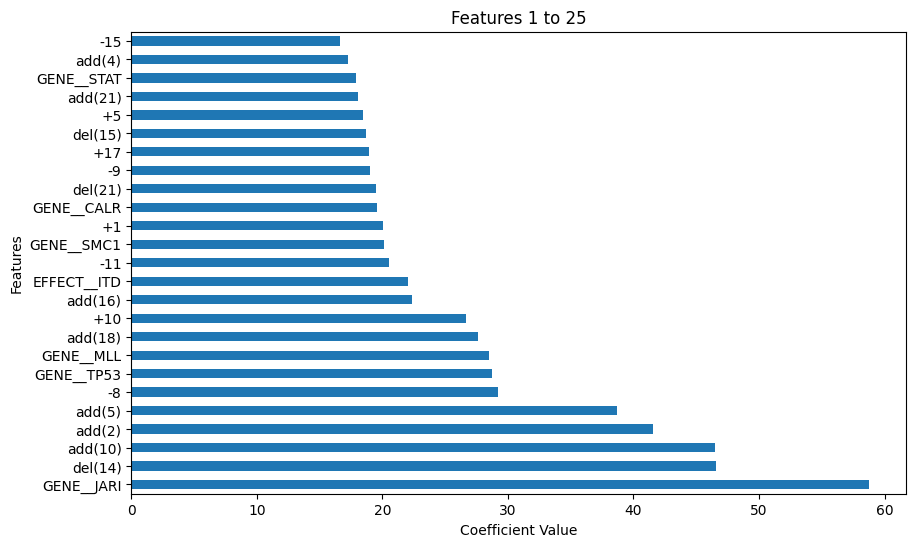

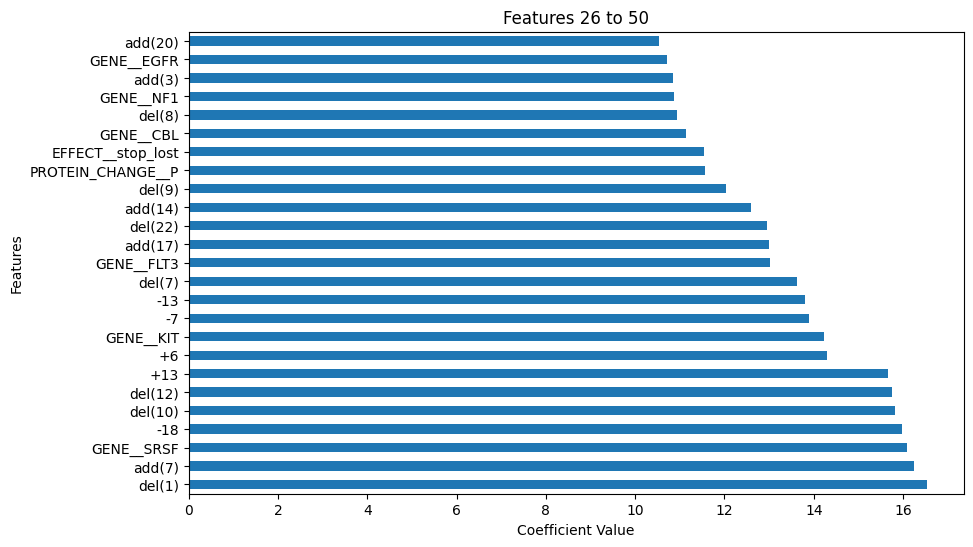

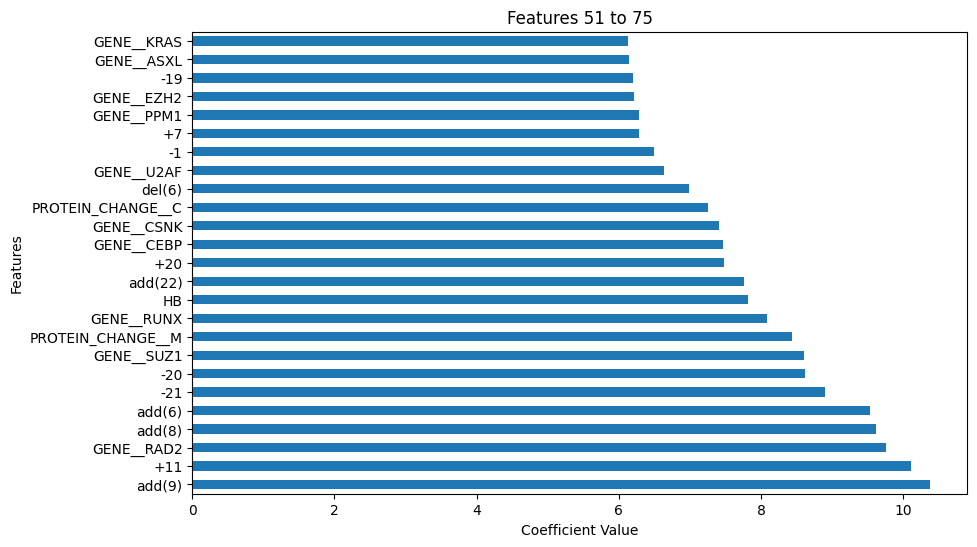

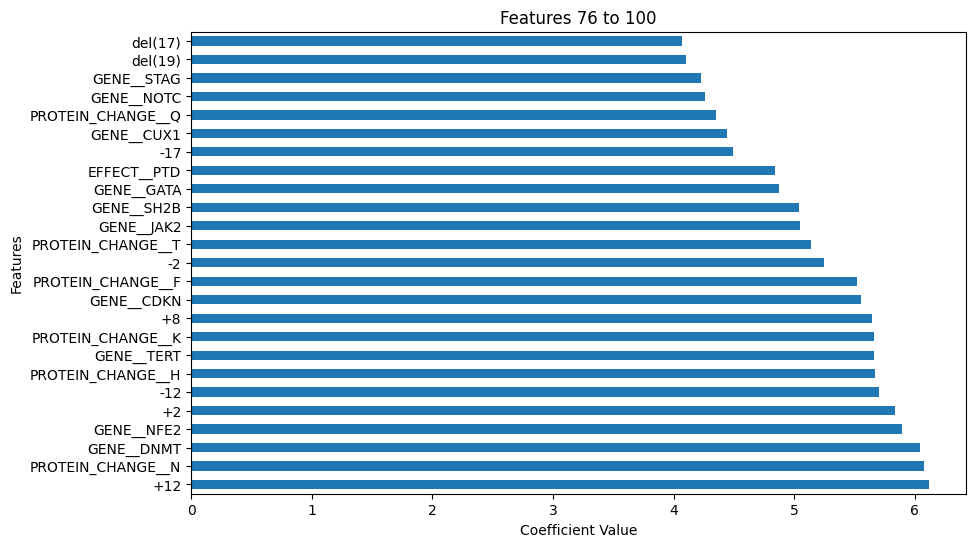

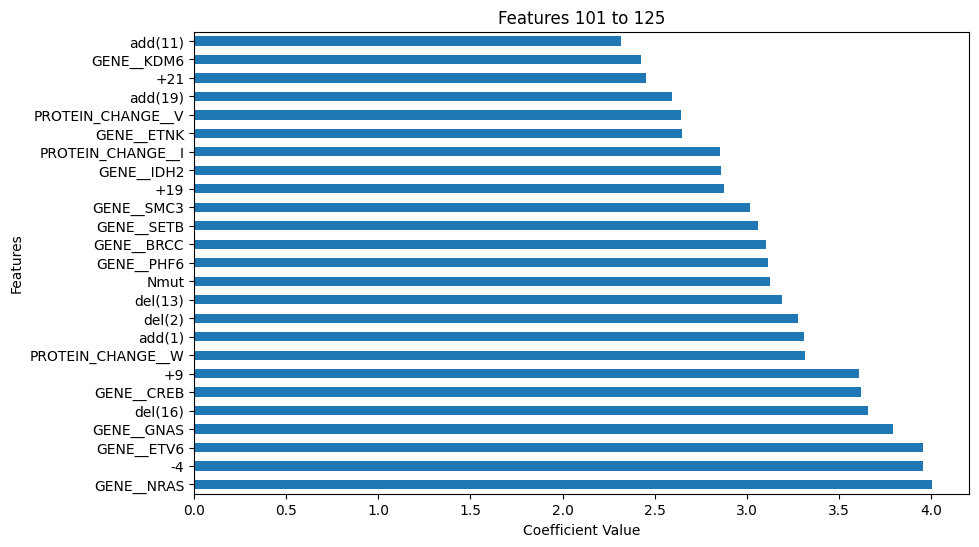

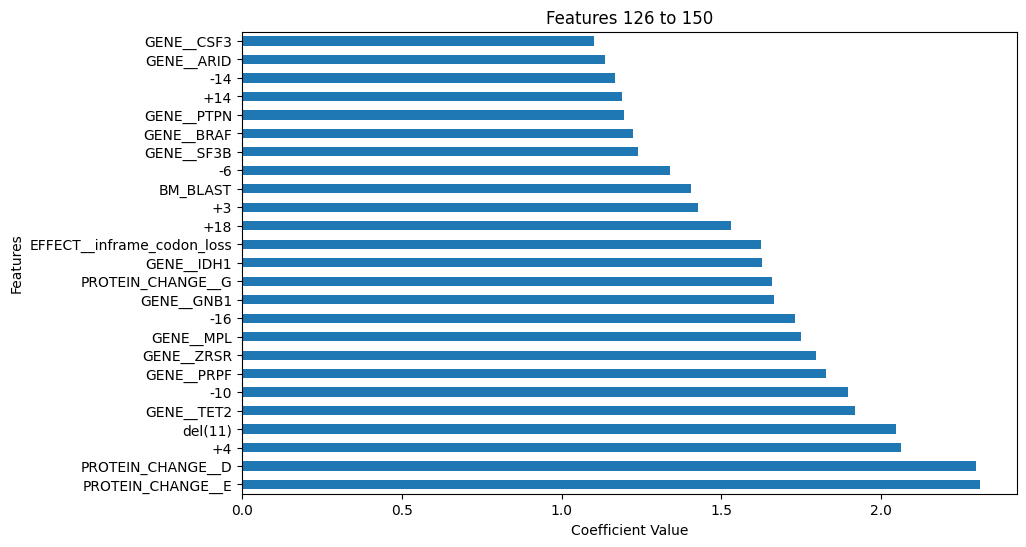

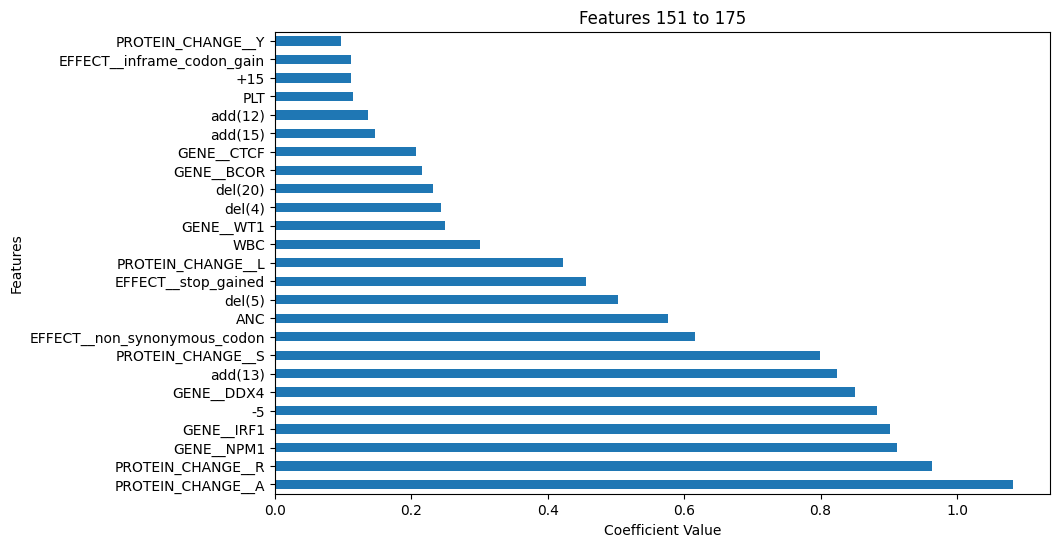

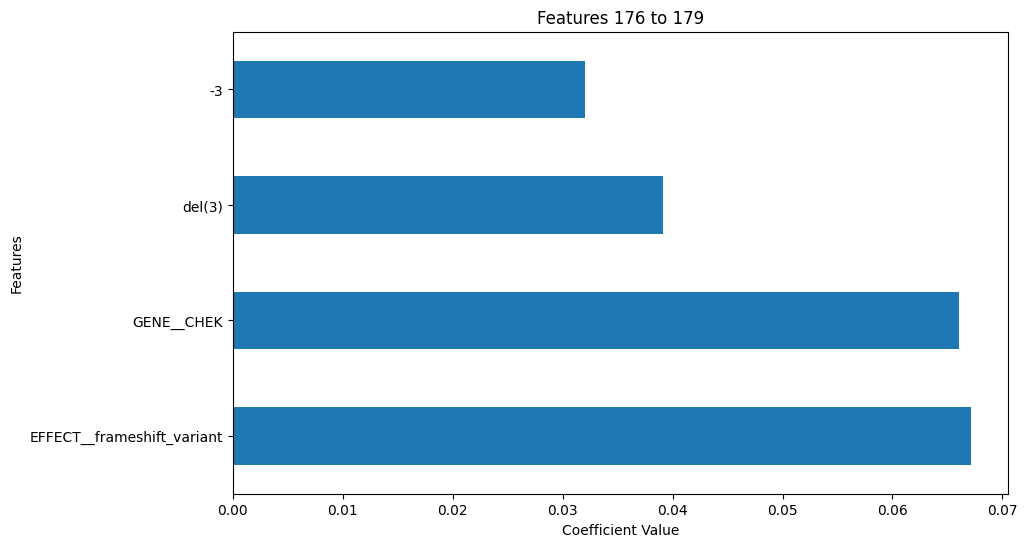

In [10]:
# Print non-zero coefficients number for each feature in chunks of 25
coefs = pd.Series(np.abs(cox.coef_).sum(axis=1), index=X_train.columns)
coefs = coefs.sort_values(ascending=False)
coefs = coefs[coefs > 0]

plt.figure(figsize=(10, 6))
chunk_size = 25
for i in range(0, len(coefs), chunk_size):
    chunk = coefs.iloc[i:i + chunk_size]
    plt.figure(figsize=(10, 6))
    chunk.plot(kind='barh')
    plt.title(f'Features {i + 1} to {i + len(chunk)}')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Features')
    plt.show()

relevant_features = coefs.index.tolist()

### 4. Prediction

3. Align colums of X_eval with those of X_train

In [11]:
X_eval = merged_eval[['ID'] + list(total_features)].copy()
X_eval.head()

,ID,GENE__CHEK,GENE__GATA,GENE__DDX4,+18,+5,GENE__ARID,GENE__NPM1,+15,GENE__GNAS,...,BM_BLAST,del(21),EFFECT__inframe_codon_loss,-10,+1,GENE__MLL,+7,add(21),PROTEIN_CHANGE__I,GENE__TET2
0,KYW1,False,False,False,0,0,False,True,0,False,...,68.0,0,False,0,0,False,0,0,False,False
1,KYW2,False,False,False,0,0,False,False,0,False,...,35.0,0,False,0,0,False,0,0,False,False
2,KYW3,False,False,False,0,0,False,False,0,False,...,NaN,0,False,0,0,False,0,0,False,True
3,KYW4,False,False,False,0,0,False,False,0,False,...,61.0,0,False,0,0,False,0,0,False,False
4,KYW5,False,False,False,0,0,False,False,0,False,...,2.0,0,False,0,0,False,0,0,False,False


3. Imputer with median strategy

In [12]:
imputer = SimpleImputer(strategy='median')
print(features)
X_train[features] = imputer.fit_transform(X_train[features])
X_eval[features] = imputer.transform(X_eval[features])
X_eval = X_eval.fillna(False)
X_eval = X_eval.drop(columns=['ID'], errors='ignore')
X_eval.head()

['BM_BLAST', 'HB', 'PLT', 'Nmut', 'ANC', 'WBC']


/tmp/ipykernel_66674/3996311209.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_eval = X_eval.fillna(False)


,GENE__CHEK,GENE__GATA,GENE__DDX4,+18,+5,GENE__ARID,GENE__NPM1,+15,GENE__GNAS,GENE__SUZ1,...,BM_BLAST,del(21),EFFECT__inframe_codon_loss,-10,+1,GENE__MLL,+7,add(21),PROTEIN_CHANGE__I,GENE__TET2
0,False,False,False,0,0,False,True,0,False,False,...,68.0,0,False,0,0,False,0,0,False,False
1,False,False,False,0,0,False,False,0,False,False,...,35.0,0,False,0,0,False,0,0,False,False
2,False,False,False,0,0,False,False,0,False,False,...,3.5,0,False,0,0,False,0,0,False,True
3,False,False,False,0,0,False,False,0,False,False,...,61.0,0,False,0,0,False,0,0,False,False
4,False,False,False,0,0,False,False,0,False,False,...,2.0,0,False,0,0,False,0,0,False,False


4. Compare percetage of False in X_train/X_eval

In [13]:
for col in X_train.columns:
    print(f"Somme dans X_train[{col}] : ", X_train[col].sum()/len(X_train))
    print(f"Somme dans X_eval[{col}] : ", X_eval[col].sum()/len(X_eval))

Somme dans X_train[GENE__CHEK] :  0.0021691973969631237
Somme dans X_eval[GENE__CHEK] :  0.004191114836546521
Somme dans X_train[GENE__GATA] :  0.021149674620390455
Somme dans X_eval[GENE__GATA] :  0.022632020117351215
Somme dans X_train[GENE__DDX4] :  0.044468546637744036
Somme dans X_eval[GENE__DDX4] :  0.06370494551550712
Somme dans X_train[+18] :  0.0016268980477223427
Somme dans X_eval[+18] :  0.00586756077116513
Somme dans X_train[+5] :  0.0016268980477223427
Somme dans X_eval[+5] :  0.008382229673093043
Somme dans X_train[GENE__ARID] :  0.014099783080260303
Somme dans X_eval[GENE__ARID] :  0.0016764459346186086
Somme dans X_train[GENE__NPM1] :  0.015184381778741865
Somme dans X_eval[GENE__NPM1] :  0.04442581726739313
Somme dans X_train[+15] :  0.004338394793926247
Somme dans X_eval[+15] :  0.0075440067057837385
Somme dans X_train[GENE__GNAS] :  0.010303687635574838
Somme dans X_eval[GENE__GNAS] :  0.00586756077116513
Somme dans X_train[GENE__SUZ1] :  0.006507592190889371
Somme d

5. Final prediction

In [14]:
prediction_on_test_set = cox.predict(X_eval)
prediction_on_test_set

array([ 2.48574659,  1.65857881, -0.01529423, ...,  0.08318779,
       -0.81557575, -0.34464556])

In [15]:
submission = pd.Series(prediction_on_test_set, index=df_eval['ID'], name='risk_score')

In [16]:
submission.to_csv('./submission/cox_ridge_submission.csv')

In [17]:
submission.head()

ID
KYW1    2.485747
KYW2    1.658579
KYW3   -0.015294
KYW4    1.295328
KYW5   -0.552140
Name: risk_score, dtype: float64